# StressNET Inference in silico

### Import necessary packages

In [1]:
import stressnet
from pathlib import Path

In [2]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

### Build StressNET model and load pretrained weights

In [3]:
stressnet.list_models()

['STRESSNET-PRETRAINED-A',
 'STRESSNET-PRETRAINED-B',
 'STRESSNET-PRETRAINED-C',
 'STRESSNET-PRETRAINED-D',
 'STRESSNET-PRETRAINED-E',
 'STRESSNET-FINETUNED-MYOSIN-88-A']

**Build the model al load pretrained weights (weights are downloaded automatically on first run)**

In [4]:
model = stressnet.load_model()  # loads 'STRESSNET-PRETRAINED-A' by default

In [5]:
model.summary()

Model: "StressNetV0.2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 edge_feats (InputLayer)        [(None, 32)]         0           []                               
                                                                                                  
 edge_feats_fc_1 (Dense)        (None, 512)          16384       ['edge_feats[0][0]']             
                                                                                                  
 edge_feats_ln_1 (LayerNormaliz  (None, 512)         1024        ['edge_feats_fc_1[0][0]']        
 ation)                                                                                           
                                                                                                  
 edge_feats_elu_1 (Activation)  (None, 512)          0           ['edge_feats_ln_1[0][

### Load a synthetic example

**Load the Surface Evolver dump file using ForSys and construct the graph for StressNET**

In [6]:
PATH_TO_SYNTHETIC_EXAMPLE = (
    Path('example_data') /
    'inference' /
    'synthetic' /
    'normal_furrow_circular' /
    'step_24.dmp'  # Surface Evolver dump file
)

In [7]:
data = stressnet.se_output_to_graph(
    src_file=PATH_TO_SYNTHETIC_EXAMPLE,
    include_forsys_predictions=True,  # also run inference with ForSys (static mode)
    return_frame=True  # we need this for plotting
)

print(
    f'A non-zero count:     {data["a"].nnz}\n'
    f'X shape:              {data["x"].shape}\n'
    f'E shape:              {data["e"].shape}\n'
    f'Y shape:              {data["y"].shape}\n'
    f'ForSys pred. shape:   {data["forsys_preds"].shape}'
)

A non-zero count:     330
X shape:              (94, 6)
E shape:              (330, 16, 2)
Y shape:              (94,)
ForSys pred. shape:   (94,)


**Check if any nodes had to be removed for being disconnected from the graph**

In [8]:
removed = data.get('removed_nodes', [])
detail = f': {removed}' if (len(removed) > 0) else ''
print(f'Removed {len(removed)} nodes{detail}')

Removed 0 nodes


**Plot the simulated tissue mesh and ground-truth stress map**

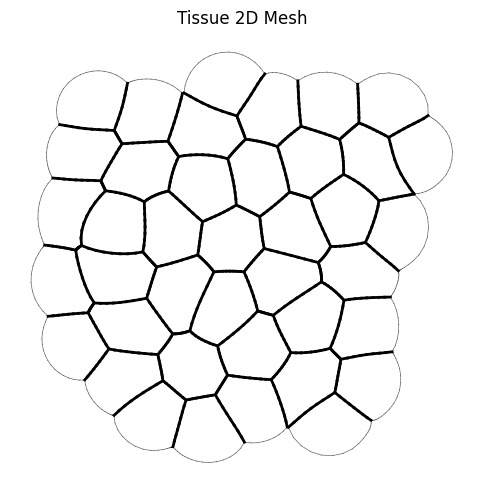

In [9]:
stressnet.plot_with_force(
    data['frame'],
    force_to_plot=None,
    figsize=(5, 5),
    title='Tissue 2D Mesh',
    plot_kwargs=dict(color='black')
)

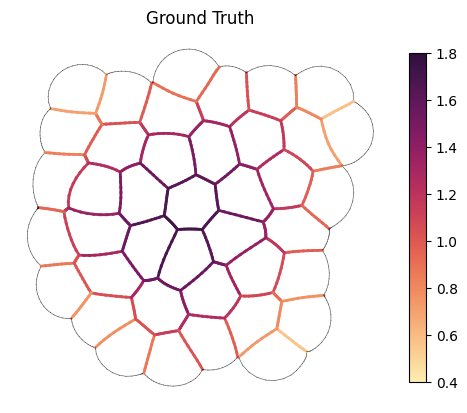

In [10]:
stressnet.plot_with_force(
    data['frame'],
    force_to_plot='gt',
    figsize=(5, 5),
    cbar=True,
    title='Ground Truth'
)

**Run inference with StressNET and compare results with ForSys**

In [11]:
# single prediction mode
stressnet_preds = stressnet.predict(
    model,
    data
)

print(f'StressNET (single prediction) shape: {stressnet_preds.shape}')

StressNET (single prediction) shape: (94,)


In [12]:
stressnet_aug_preds = stressnet.predict_augmented(
    model,
    data,
    n_augmentations=9,
    seed=1337
)

print(f'StressNET (augmented) shape: {stressnet_aug_preds.shape}')

StressNET (augmented) shape: (94,)


In [13]:
for method, predictions in [
    ('ForSys', data['forsys_preds']),
    ('StressNET (single prediction)', stressnet_preds),
    ('StressNET (augmented)', stressnet_aug_preds),
]:
    r, r2, mape, score = stressnet.calculate_metrics(data['y'], predictions)
    print(
        f'{method} Predictions vs Ground Truth Tensions:\n'
        f'  Pearson R:   {r:.3f}\n'
        f'  R^2:         {r2:.3f}\n'
        f'  MAPE:        {mape:.2f}%\n'
        f'  Score:       {score:.1f}\n',
        end='\n\n'
    )

ForSys Predictions vs Ground Truth Tensions:
  Pearson R:   0.974
  R^2:         0.944
  MAPE:        5.13%
  Score:       75.8


StressNET (single prediction) Predictions vs Ground Truth Tensions:
  Pearson R:   0.991
  R^2:         0.953
  MAPE:        4.90%
  Score:       141.4


StressNET (augmented) Predictions vs Ground Truth Tensions:
  Pearson R:   0.992
  R^2:         0.959
  MAPE:        4.56%
  Score:       145.8




**Plot predicted stress maps**

When using `include_forsys_predictions=True`, ForSys predicted stress is assigned to each edge in the `Frame` object.

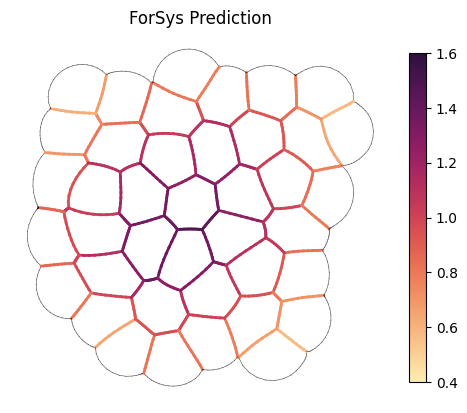

In [14]:
stressnet.plot_with_force(
    data['frame'],
    force_to_plot='stress',
    figsize=(5, 5),
    cbar=True,
    title='ForSys Prediction'
)

To display StressNET predicted stress map, get a new `Frame` object with StressNET predicted values assigned as edge tensions, then plot.

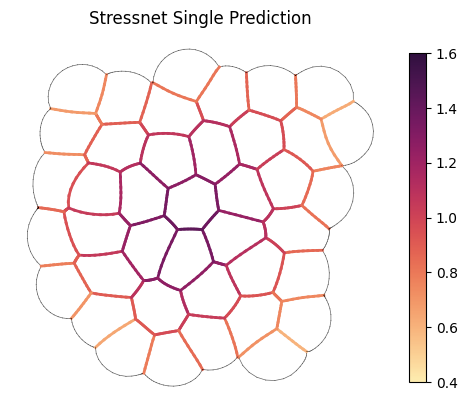

In [15]:
frame_with_stressnet_preds = stressnet.frame_with_predicted_tensions(
    data['frame'],
    stressnet_preds
)

stressnet.plot_with_force(
    frame_with_stressnet_preds,
    force_to_plot='stress',
    figsize=(5, 5),
    cbar=True,
    title='Stressnet Single Prediction'
)

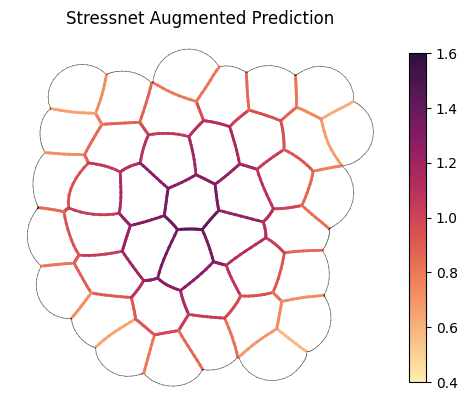

In [16]:
frame_with_stressnet_aug_preds = stressnet.frame_with_predicted_tensions(
    data['frame'],
    stressnet_aug_preds
)

stressnet.plot_with_force(
    frame_with_stressnet_aug_preds,
    force_to_plot='stress',
    figsize=(5, 5),
    cbar=True,
    title='Stressnet Augmented Prediction'
)